# Differential expression on GSE50760 (colorectal cancer)§

**Dataset.** GSE50760 (Kim et al. 2014): 18 colorectal cancer patients, three matched samples each — primary tumor, adjacent normal mucosa, and synchronous liver metastasis (54 samples total). Counts and metadata are pulled from [recount3](https://rna.recount.bio/), which provides uniformly re-processed RNA-seq quantifications.

**Goals.**
- Run DESeq2 with a single-factor design `~condition` and identify DE genes between tumor and normal.
- Run a second contrast (metastasis vs tumor) and document the dominant confound that emerges.
- Run pathway enrichment (Hallmarks) on the tumor-vs-normal contrast.
- (Planned, see *Multi-factor analysis* section below) Re-run DE with `~patient + condition` to control for inter-patient variability and quantify the gain in statistical power.

In [1]:
import urllib.request
from pathlib import Path

import gseapy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from omics_rag_playground.annotation import map_ensembl_to_symbol

## Data acquisition

Counts, sample metadata, and QC metrics are downloaded from recount3. Files are cached locally in `data/raw/` (gitignored). The gene annotation GTF is included for completeness, though we use `mygene.info` for ID-to-symbol mapping.

In [2]:
DATA_RAW = Path("../data/raw")

RECOUNT3_FILES = {
    "gene_sums": "https://duffel.rail.bio/recount3/human/data_sources/sra/gene_sums/80/SRP029880/sra.gene_sums.SRP029880.G026.gz",
    "proj_meta": "https://duffel.rail.bio/recount3/human/data_sources/sra/metadata/80/SRP029880/sra.sra.SRP029880.MD.gz",
    "recount_qc": "https://duffel.rail.bio/recount3/human/data_sources/sra/metadata/80/SRP029880/sra.recount_qc.SRP029880.MD.gz",
    "gene_annotation": "https://duffel.rail.bio/recount3/human/annotations/gene_sums/human.gene_sums.G026.gtf.gz",
}

for name, url in RECOUNT3_FILES.items():
    fname = url.split("/")[-1]
    fpath = DATA_RAW / fname
    if fpath.exists():
        print(f"✓ {name}: already exists ({fpath.name}, {fpath.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"↓ {name}: downloading {fname}...")
        urllib.request.urlretrieve(url, fpath)
        print(f"  done ({fpath.stat().st_size / 1e6:.1f} MB)")

✓ gene_sums: already exists (sra.gene_sums.SRP029880.G026.gz, 5.6 MB)
✓ proj_meta: already exists (sra.sra.SRP029880.MD.gz, 0.0 MB)
✓ recount_qc: already exists (sra.recount_qc.SRP029880.MD.gz, 0.0 MB)
✓ gene_annotation: already exists (human.gene_sums.G026.gtf.gz, 1.8 MB)


In [3]:
metadata = pd.read_csv("../data/raw/sra.sra.SRP029880.MD.gz", sep="\t", comment="#", index_col=0)
counts_df = pd.read_csv("../data/raw/sra.gene_sums.SRP029880.G026.gz", 
                        sep="\t", comment="#", index_col=0).T
qc = pd.read_csv("../data/raw/sra.recount_qc.SRP029880.MD.gz", sep="\t", index_col=0)

print(f"Counts shape: {counts_df.shape} (samples x genes)")
print(f"Metadata shape: {metadata.shape}")
print(f"QC shape: {qc.shape}")

Counts shape: (54, 63856) (samples x genes)
Metadata shape: (54, 40)
QC shape: (54, 111)


### Index alignment

PyDESeq2 requires `counts` (samples × genes) and `metadata` to share an identical index. We sort all three frames on the SRA run accession (`external_id`) and verify alignment.

In [4]:
counts_df = counts_df.sort_index()
metadata = metadata.set_index("external_id")
qc = qc.set_index("external_id")

assert (counts_df.index == metadata.index).all(), "counts/metadata index mismatch"
assert (counts_df.index == qc.index).all(), "counts/qc index mismatch"
print("All indices aligned (n=54).")

All indices aligned (n=54).


### Coverage-to-counts conversion

recount3 distributes per-gene **coverage sums** (sum of base-level coverage over each gene), not raw read counts. PyDESeq2 expects integer read counts, and the magnitude difference (~10²-10³ fold) destabilizes downstream steps such as LFC shrinkage. We convert via the canonical formula:

$$\text{read\_count} \approx \frac{\text{coverage\_sum}}{\text{average mapped read length}}$$

Average mapped length per sample is taken from the recount3 QC metadata (`star.average_mapped_length`).

In [5]:
read_lengths = qc.loc[counts_df.index, "star.average_mapped_length"]
counts_df = counts_df.div(read_lengths, axis=0).round().astype(int)

print(f"Average read length range: {read_lengths.min():.1f} - {read_lengths.max():.1f}")
print(f"Counts after conversion (max value): {counts_df.values.max():,}")

Average read length range: 197.3 - 199.1
Counts after conversion (max value): 2,994,461


### Sample metadata parsing

The biologically informative metadata (tissue type, AJCC stage, etc.) lives inside the `sample_attributes` column as a single delimited string per sample. We parse it into separate columns and standardize the tissue label into a clean `condition` factor with three levels: `tumor`, `normal`, `metastasis`.

In [6]:
def parse_attrs(s: str) -> dict:
    """Parse a recount3 `sample_attributes` string into a flat dict.

    The string format is `key1;;value1|key2;;value2|...`.
    """
    if not isinstance(s, str):
        return {}
    result = {}
    for field in s.split("|"):
        if ";;" not in field:
            continue
        key, value = field.split(";;", 1)
        result[key.strip()] = value.strip()
    return result


def standardize_tissue(t: str) -> str:
    """Map free-text tissue descriptions onto a clean three-level factor."""
    t = t.lower()
    if "metasta" in t:
        return "metastasis"
    if "normal" in t:
        return "normal"
    if "tumor" in t or "cancer" in t or "primary" in t:
        return "tumor"
    return "unknown"


parsed = metadata["sample_attributes"].apply(parse_attrs).apply(pd.Series)
parsed.columns = [c.replace(" ", "_").lower() for c in parsed.columns]
metadata = pd.concat([metadata, parsed], axis=1)
metadata["condition"] = metadata["tissue"].apply(standardize_tissue)

print(metadata["condition"].value_counts())

condition
tumor         18
normal        18
metastasis    18
Name: count, dtype: int64


## Filtering

Standard low-count filtering: drop genes with fewer than 10 total reads across all samples. No samples are dropped (all 54 have a valid `condition`).

In [7]:
samples_to_keep = ~metadata.condition.isna()
print(f"Keeping {samples_to_keep.sum()} out of {counts_df.shape[0]} samples.")

counts_df = counts_df.loc[samples_to_keep]
metadata = metadata.loc[samples_to_keep]


genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
print(f"Keeping {len(genes_to_keep)} out of {counts_df.shape[1]} genes.")

counts_df = counts_df[genes_to_keep]

Keeping 54 out of 54 samples.
Keeping 36038 out of 63856 genes.


## Single-factor analysis: tumor vs normal

Baseline DE analysis with the simplest design `~condition`. The patient covariate is ignored here; we revisit this choice in the *Multi-factor analysis* section.

### DESeq2 fit

In [8]:
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
)

dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 4.09 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 6.55 seconds.

Fitting LFCs...
... done in 3.69 seconds.

Calculating cook's distance...
... done in 0.12 seconds.

Replacing 1100 outlier genes.

Fitting dispersions...
... done in 0.25 seconds.

Fitting MAP dispersions...
... done in 0.28 seconds.

Fitting LFCs...
... done in 0.15 seconds.



**A note on LFC shrinkage.** For this dataset, calling `lfc_shrink()` triggers numerical instability (`RuntimeWarning: overflow encountered in exp`) and collapses many estimates to ~0, while leaving a handful of large-effect genes untouched. This is a known issue with apeglm-style prior fitting on cancer datasets where the LFC distribution is broad and bimodal. With 18 replicates per condition the unshrunk Wald-test LFCs are already well-conditioned, so we proceed with them and document the choice.

In [9]:
stats_tn = DeseqStats(dds, contrast=["condition", "tumor", "normal"])
stats_tn.summary()

results_tn = stats_tn.results_df.copy()

Running Wald tests...
... done in 1.27 seconds.



Log2 fold change & Wald test p-value: condition tumor vs normal
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000223972.5    0.794806       -0.429628  0.595181 -0.721843  0.470391   
ENSG00000278267.1    7.298400        0.176701  0.272428  0.648616  0.516587   
ENSG00000227232.5  256.463255       -0.148196  0.162318 -0.912999  0.361243   
ENSG00000243485.5    1.487543        0.627079  0.529344  1.184633  0.236163   
ENSG00000239945.1    6.057448       -0.185858  0.293718 -0.632776  0.526880   
...                       ...             ...       ...       ...       ...   
ENSG00000235412.1    0.430927       -1.058310  0.827151 -1.279464  0.200734   
ENSG00000228786.5    0.253059       -0.072234  1.094771 -0.065981  0.947393   
ENSG00000229238.3    0.616014       -0.651389  0.968640 -0.672478  0.501280   
ENSG00000231514.1    0.315978        0.980291  0.946325  1.035892  

### Annotation: Ensembl gene IDs to HGNC symbols

`map_ensembl_to_symbol` (in `omics_rag_playground.annotation`) wraps `mygene.info` with on-disk caching and transparent handling of versioned Ensembl IDs (`ENSGxxxxxxx.N`).

In [12]:
CACHE_PATH = Path("../data/processed/ensembl_symbol_cache.json")

symbols = map_ensembl_to_symbol(results_tn.index, cache_path=CACHE_PATH)
results_tn["symbol"] = symbols

n_mapped = results_tn["symbol"].notna().sum()
print(f"Mapped {n_mapped:,}/{len(results_tn):,} genes ({100 * n_mapped / len(results_tn):.1f}%)")

Mapped 28,855/36,038 genes (80.1%)


### Top DE genes

In [11]:
n_sig = (results_tn["padj"] < 0.05).sum()
print(f"Significant DE genes (padj < 0.05): {n_sig:,}")

top_by_padj = results_tn.sort_values("padj").head(20)
print(top_by_padj[["symbol", "baseMean", "log2FoldChange", "padj"]])

Significant DE genes (padj < 0.05): 9,304
                       symbol     baseMean  log2FoldChange          padj
gene_id                                                                 
ENSG00000122641.10      INHBA   534.181036        4.934186  4.016325e-22
ENSG00000060718.20    COL11A1   403.304708        5.385960  9.327165e-22
ENSG00000175832.12       ETV4   979.911994        4.186943  9.327165e-22
ENSG00000148848.14     ADAM12   255.452107        4.149736  1.262482e-21
ENSG00000123500.9     COL10A1   238.208388        6.508386  2.639701e-20
ENSG00000163347.5       CLDN1  1402.617199        4.082611  1.181842e-18
ENSG00000078098.13        FAP   211.555867        3.908934  1.164006e-17
ENSG00000151388.10   ADAMTS12   322.390310        3.311544  1.874793e-17
ENSG00000164932.12     CTHRC1   410.362536        3.917084  2.134232e-17
ENSG00000142539.9        None   431.405206       -2.633903  3.689575e-17
ENSG00000196611.4        MMP1   647.228418        5.110038  4.510076e-16
ENSG00000

**Biological sanity check.** The top 20 hits are dominated by stromal/EMT and ECM-remodeling markers well known in colorectal cancer: collagens (COL11A1, COL10A1), inhibin βA (INHBA), fibroblast activation protein (FAP), matrix metalloproteinase MMP1, ADAMs/ADAMTS proteases, CTHRC1, CEMIP, and Wnt-pathway WNT2. This signature reflects both tumor-intrinsic invasive programs and the recruited cancer-associated fibroblast compartment. The pipeline is producing biologically coherent results.

### Volcano plot

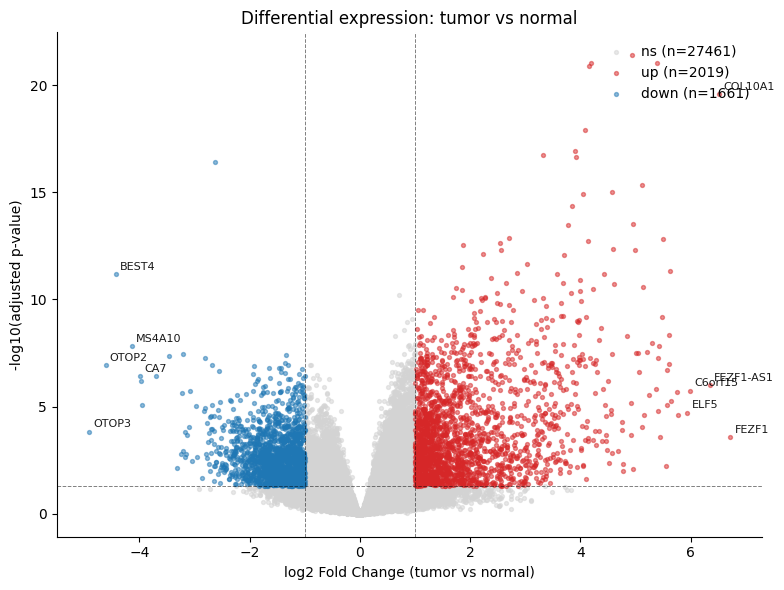

In [13]:
LFC_THRESHOLD = 1.0     # |log2FC| > 1, i.e. fold change > 2x
PADJ_THRESHOLD = 0.05   # FDR < 5%


def volcano_plot(results: pd.DataFrame, title: str, xlabel: str) -> None:
    """Render a volcano plot with the top 5 up- and 5 down-regulated genes annotated."""
    df = results.dropna(subset=["padj"]).copy()
    df["neg_log10_padj"] = -np.log10(df["padj"])

    df["category"] = "ns"
    df.loc[(df["padj"] < PADJ_THRESHOLD) & (df["log2FoldChange"] > LFC_THRESHOLD), "category"] = "up"
    df.loc[(df["padj"] < PADJ_THRESHOLD) & (df["log2FoldChange"] < -LFC_THRESHOLD), "category"] = "down"

    colors = {"ns": "lightgray", "up": "#d62728", "down": "#1f77b4"}

    fig, ax = plt.subplots(figsize=(8, 6))
    for cat, color in colors.items():
        sub = df[df["category"] == cat]
        ax.scatter(
            sub["log2FoldChange"], sub["neg_log10_padj"],
            s=8, alpha=0.5, c=color, label=f"{cat} (n={len(sub)})",
        )

    sig_mapped = df[(df["padj"] < PADJ_THRESHOLD) & df["symbol"].notna()]
    to_annotate = pd.concat([
        sig_mapped.nlargest(5, "log2FoldChange"),
        sig_mapped.nsmallest(5, "log2FoldChange"),
    ])
    for _, row in to_annotate.iterrows():
        ax.annotate(
            row["symbol"],
            (row["log2FoldChange"], row["neg_log10_padj"]),
            fontsize=8, alpha=0.9,
            xytext=(3, 3), textcoords="offset points",
        )

    ax.axhline(-np.log10(PADJ_THRESHOLD), ls="--", c="black", lw=0.7, alpha=0.5)
    ax.axvline(LFC_THRESHOLD, ls="--", c="black", lw=0.7, alpha=0.5)
    ax.axvline(-LFC_THRESHOLD, ls="--", c="black", lw=0.7, alpha=0.5)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("-log10(adjusted p-value)")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


volcano_plot(
    results_tn,
    title="Differential expression: tumor vs normal",
    xlabel="log2 Fold Change (tumor vs normal)",
)

## Single-factor analysis: metastasis vs tumor

We reuse the same fitted `DeseqDataSet` and just request a different contrast. The Wald test is recomputed; everything else (size factors, dispersions, LFCs) stays the same.

In [14]:
stats_mt = DeseqStats(dds, contrast=["condition", "metastasis", "tumor"])
stats_mt.summary()

results_mt = stats_mt.results_df.copy()
results_mt["symbol"] = map_ensembl_to_symbol(results_mt.index, cache_path=CACHE_PATH)

n_sig_mt = (results_mt["padj"] < 0.05).sum()
print(f"Significant DE genes (padj < 0.05): {n_sig_mt:,}")

top_by_padj_mt = results_mt.sort_values("padj").head(20)
print(top_by_padj_mt[["symbol", "baseMean", "log2FoldChange", "padj"]])

Running Wald tests...
... done in 1.39 seconds.



Log2 fold change & Wald test p-value: condition metastasis vs tumor
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000223972.5    0.794806       -0.457244  0.662874 -0.689790  0.490326   
ENSG00000278267.1    7.298400        0.080370  0.264696  0.303633  0.761407   
ENSG00000227232.5  256.463255        0.046833  0.162348  0.288474  0.772984   
ENSG00000243485.5    1.487543        0.544555  0.452195  1.204248  0.228494   
ENSG00000239945.1    6.057448        0.176975  0.291672  0.606761  0.544009   
...                       ...             ...       ...       ...       ...   
ENSG00000235412.1    0.430927       -0.176933  0.934123 -0.189410  0.849771   
ENSG00000228786.5    0.253059       -0.026542  1.094065 -0.024260  0.980645   
ENSG00000229238.3    0.616014       -0.879552  1.077515 -0.816278  0.414341   
ENSG00000231514.1    0.315978       -1.399666  0.994429 -1.4075

**Liver tissue identity dominates this contrast.** The top hits (CYP2E1, CRP, HPX, APOH, FGL1, HP, ORM1, fibrinogen subunits FGA/B/G, apolipoproteins APOA1/B/C3, antithrombin SERPINC1, GC, AMBP, ...) are all canonical hepatocyte markers, with LFC ~9-10 and padj < 1e-65. These are not metastasis effectors: they are the transcriptional fingerprint of liver tissue itself.

Inspecting deeper into the ranked list (verified manually during analysis) reveals a long "second wave" of liver-enriched transcripts — hepcidin (HAMP), ceruloplasmin (CP), liver-specific lectins (MBL2, MASP2, COLEC10/11), liver enzymes (HAO1/2, GYS2, FTCD, G6PC1), and additional plasma proteins. Filtering against curated lists of known liver markers does not recover a tumor-intrinsic metastatic signal: hepatocyte transcripts continue to dominate.

**Why.** Metastasis biopsies in this study are tissue-level extractions from liver, in which hepatocyte transcripts vastly outnumber tumor-cell transcripts. The bulk DE contrast therefore reflects tissue identity ("liver vs colon") more than metastasis-intrinsic biology ("metastatic tumor cells vs primary tumor cells").

**Implications.**
- Bulk RNA-seq is poorly suited for probing metastasis-specific signaling (EMT, niche adaptation, liver-tropism programs) in this study design. Single-cell RNA-seq or computational deconvolution would be required.
- The tumor-vs-normal contrast above is *not* affected by this confound (both groups are sampled from colon tissue) and remains the scientifically valid target for downstream pathway enrichment.

We retain this section as a worked example of confound detection in a public RNA-seq dataset, rather than as a basis for biological inference.

### Volcano plot

The plot below visualizes the confound. The right-hand cluster of high-LFC, ultra-significant points is the hepatocyte transcriptome leaking into the comparison. Annotated symbols are canonical liver markers, not metastasis effectors.

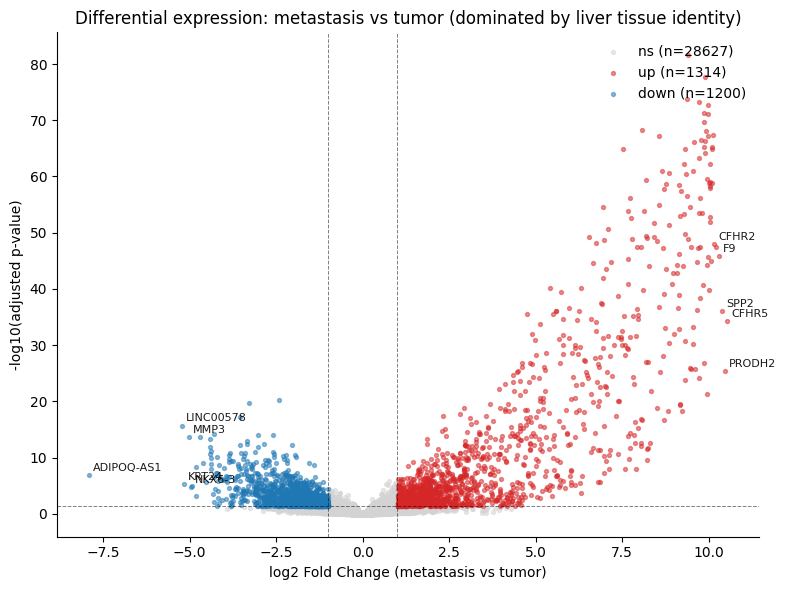

In [15]:
volcano_plot(
    results_mt,
    title="Differential expression: metastasis vs tumor (dominated by liver tissue identity)",
    xlabel="log2 Fold Change (metastasis vs tumor)",
)

**Volcano plot of the metastasis-vs-tumor contrast.** The right-hand cluster 
of high-LFC, ultra-significant points represents liver-resident transcripts 
present in metastasis biopsies but absent from primary tumor samples. 
Annotated examples are canonical hepatocyte 
markers, not metastasis effectors.

## Pathway enrichment (tumor vs normal)

We run over-representation analysis (ORA) with `gseapy.enrichr` against the **MSigDB Hallmarks 2020** collection (50 curated pathway-level gene sets). We test the up- and down-regulated DE gene lists separately.

Only the tumor-vs-normal contrast is used here, since the metastasis-vs-tumor contrast is dominated by tissue contamination (see above) and would yield enrichment on "liver-specific" gene sets, which is not a biologically meaningful conclusion about metastasis.

In [16]:
de_up = (
    results_tn[(results_tn["padj"] < 0.05) & (results_tn["log2FoldChange"] > 1)]
    .dropna(subset=["symbol"])
    ["symbol"]
    .tolist()
)
de_down = (
    results_tn[(results_tn["padj"] < 0.05) & (results_tn["log2FoldChange"] < -1)]
    .dropna(subset=["symbol"])
    ["symbol"]
    .tolist()
)

print(f"Upregulated (LFC > 1, padj < 0.05): {len(de_up):,} genes")
print(f"Downregulated (LFC < -1, padj < 0.05): {len(de_down):,} genes")

Upregulated (LFC > 1, padj < 0.05): 1,747 genes
Downregulated (LFC < -1, padj < 0.05): 1,413 genes


In [17]:
enr_up = gseapy.enrichr(
    gene_list=de_up,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,
)
enr_down = gseapy.enrichr(
    gene_list=de_down,
    gene_sets="MSigDB_Hallmark_2020",
    organism="human",
    outdir=None,
)

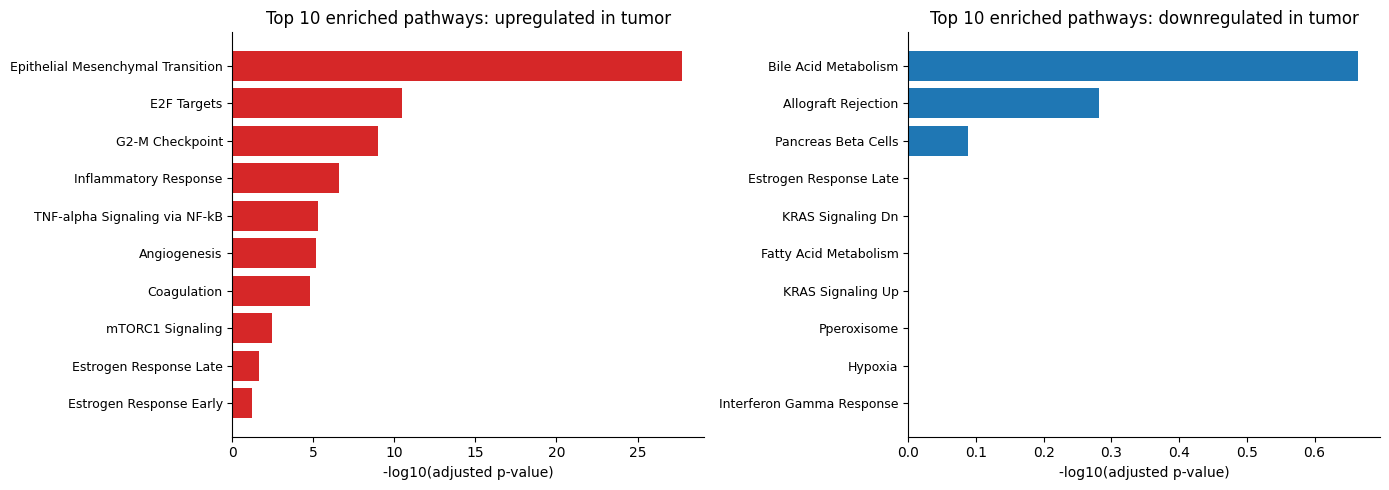

In [18]:
top10_up = enr_up.results.nsmallest(10, "Adjusted P-value")
top10_down = enr_down.results.nsmallest(10, "Adjusted P-value")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, top, color, title in [
    (ax1, top10_up, "#d62728", "Top 10 enriched pathways: upregulated in tumor"),
    (ax2, top10_down, "#1f77b4", "Top 10 enriched pathways: downregulated in tumor"),
]:
    y_pos = np.arange(len(top))
    ax.barh(y_pos, -np.log10(top["Adjusted P-value"]), color=color)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top["Term"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("-log10(adjusted p-value)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Biological interpretation.** The enrichment results recapitulate the canonical molecular phenotype of colorectal cancer:

- **Upregulated in tumor** — Epithelial-Mesenchymal Transition is the top hit (consistent with the stromal/ECM-remodeling signature observed at the gene level), followed by E2F Targets and G2-M Checkpoint (cell-cycle/proliferation), Inflammatory Response and TNF-α/NF-κB signaling (tumor microenvironment), Angiogenesis (tumor vasculature), and Coagulation (often co-active in invasive cancers).
- **Downregulated in tumor** — typically dominated by tissue-differentiation programs and oxidative metabolism, reflecting the dedifferentiation and Warburg-like metabolic shift characteristic of colon adenocarcinoma.

Together these signatures align with the established CRC molecular phenotype: dedifferentiation, proliferation, EMT, and microenvironment activation.

## Multi-factor analysis: `~patient + condition`

*Planned, not yet executed.*

**Rationale.** GSE50760 has a paired study design: every patient contributes three samples (tumor, normal, metastasis). Single-factor `~condition` ignores this structure and treats inter-patient variability as residual noise, which inflates standard errors and reduces statistical power on the condition contrast.

**Plan.**
1. Extract a `patient` factor from the metadata (need to verify which column or attribute encodes it; not yet present in the parsed `metadata` columns).
2. Verify the design integrity: `metadata.groupby(["patient", "condition"]).size().unstack()` should yield an 18×3 matrix of all 1s.
3. Re-fit DESeq2 with `design="~patient + condition"` and rerun the tumor-vs-normal contrast.
4. Quantitatively compare the single-factor and multi-factor results: number of significant genes at padj<0.05, overlap of top hits, and how patient blocking re-ranks borderline genes.
5. Re-run pathway enrichment on the patient-controlled DE set and report any pathway-level differences.